In [1]:
import os
os.environ["HF_HOME"] = "C:/huggingface_cache"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from datasets import load_dataset
import pandas as pd

print("Loading Polyvore...")
ds_poly = load_dataset("Marqo/polyvore", split="data")
df_poly = ds_poly.remove_columns(["image"]).to_pandas()

print(f"Total rows: {len(df_poly)}")
print(f"Columns: {df_poly.columns.tolist()}")
print(f"\nSample rows:")
print(df_poly.head(10))

# Extract outfit ID and position
df_poly["outfit_id"] = df_poly["item_ID"].str.rsplit("_", n=1).str[0]
df_poly["position"]  = df_poly["item_ID"].str.rsplit("_", n=1).str[1]

print(f"\nUnique outfits: {df_poly['outfit_id'].nunique()}")
print(f"Unique items: {df_poly['item_ID'].nunique()}")
print(f"\nTop categories:")
print(df_poly["category"].value_counts().head(20))

c:\Users\shriy\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading Polyvore...
Total rows: 94096
Columns: ['category', 'text', 'item_ID']

Sample rows:
       category                                           text      item_ID
0   Day Dresses                    tibi knit long sleeve dress  100002074_1
1         Boots       michael kors leather over-the-knee boots  100002074_2
2      Handbags  givenchy leather medium antigona duffel black  100002074_3
3    Sunglasses      bottega veneta acetate leather sunglasses  100002074_4
4  Floral Decor                              pier imports stem  100002074_5
5         Coats                                   miranda coat  100002074_7
6       Blazers                            three pocket blazer  100010727_1
7  Skinny Jeans                           givenchy skinny jean  100010727_2
8       Watches      guess black silver-tone chronograph watch  100010727_4
9    Sunglasses           ray-ban original wayfarer sunglasses  100010727_5

Unique outfits: 21587
Unique items: 94096

Top categories:
category
Ea

In [2]:
# Add this once near your other initializations
import json
import os

FEEDBACK_FILE = "user_feedback.json"

def load_feedback():
    if os.path.exists(FEEDBACK_FILE):
        with open(FEEDBACK_FILE) as f:
            return json.load(f)
    return {"liked": [], "disliked": []}

def save_feedback(feedback):
    with open(FEEDBACK_FILE, "w") as f:
        json.dump(feedback, f)

feedback_store = load_feedback()

In [3]:
# Define which Polyvore categories are tops and bottoms
TOP_CATEGORIES = [
    "Tops", "T-Shirts", "Blouses", "Sweaters", "Sweatshirts",
    "Tank Tops", "Men's Shirts", "Blazers", "Jackets", "Coats",
    "Vests", "Intimates"
]

BOTTOM_CATEGORIES = [
    "Skinny Jeans", "Boyfriend Jeans", "Shorts", "Skirts",
    "Pants", "Leggings", "Joggers", "Trousers", "Jeans",
    "Day Dresses", "Rompers"
]

df_poly["garment_type"] = None
df_poly.loc[df_poly["category"].isin(TOP_CATEGORIES), "garment_type"]    = "top"
df_poly.loc[df_poly["category"].isin(BOTTOM_CATEGORIES), "garment_type"] = "bottom"

# Keep only tops and bottoms
df_poly_filtered = df_poly[df_poly["garment_type"].notna()].copy()

print(f"After filtering: {len(df_poly_filtered)} items")
print(df_poly_filtered["garment_type"].value_counts())
print(f"\nUnique outfits with tops/bottoms: {df_poly_filtered['outfit_id'].nunique()}")

After filtering: 22662 items
garment_type
top       14543
bottom     8119
Name: count, dtype: int64

Unique outfits with tops/bottoms: 14988


In [4]:
import random
random.seed(42)

pairs = []
seen  = set()

# Group by outfit
outfit_groups = df_poly_filtered.groupby("outfit_id")

# Positive pairs — top + bottom from SAME outfit
for outfit_id, group in outfit_groups:
    tops    = group[group["garment_type"] == "top"]["item_ID"].tolist()
    bottoms = group[group["garment_type"] == "bottom"]["item_ID"].tolist()
    
    if len(tops) == 0 or len(bottoms) == 0:
        continue
    
    for top in tops:
        for bottom in bottoms:
            pair_id = (top, bottom)
            if pair_id in seen:
                continue
            seen.add(pair_id)
            pairs.append({
                "item_A": top,
                "item_B": bottom,
                "label":  1   # REAL compatible pair
            })

print(f"Positive pairs created: {len(pairs)}")

# Negative pairs — top from one outfit + bottom from DIFFERENT outfit
all_tops    = df_poly_filtered[df_poly_filtered["garment_type"] == "top"]["item_ID"].tolist()
all_bottoms = df_poly_filtered[df_poly_filtered["garment_type"] == "bottom"]["item_ID"].tolist()

# Build outfit lookup for fast checking
item_to_outfit = dict(zip(df_poly_filtered["item_ID"], df_poly_filtered["outfit_id"]))

neg_count    = 0
neg_attempts = 0
target_negs  = len(pairs)  # equal positive and negative

while neg_count < target_negs:
    neg_attempts += 1
    if neg_attempts > target_negs * 20:
        print(f"Could only make {neg_count} negative pairs")
        break
    
    top    = random.choice(all_tops)
    bottom = random.choice(all_bottoms)
    
    # Make sure they're from DIFFERENT outfits
    if item_to_outfit[top] == item_to_outfit[bottom]:
        continue
    
    pair_id = (top, bottom)
    if pair_id in seen:
        continue
    
    seen.add(pair_id)
    pairs.append({
        "item_A": top,
        "item_B": bottom,
        "label":  0   # REAL incompatible pair
    })
    neg_count += 1

pairs_df_poly = pd.DataFrame(pairs)
print(f"\nTotal pairs: {len(pairs_df_poly)}")
print(f"Positive: {len(pairs_df_poly[pairs_df_poly['label'] == 1])}")
print(f"Negative: {len(pairs_df_poly[pairs_df_poly['label'] == 0])}")

Positive pairs created: 5969

Total pairs: 11938
Positive: 5969
Negative: 5969


In [5]:
# Check if images exist
ds_poly = load_dataset("Marqo/polyvore", split="data")
print(ds_poly.column_names)
print(ds_poly[0])

['image', 'category', 'text', 'item_ID']
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=274x400 at 0x1D80A20BB60>, 'category': 'Day Dresses', 'text': 'tibi knit long sleeve dress', 'item_ID': '100002074_1'}


In [6]:
import open_clip
import torch
from PIL import Image
import io
import numpy as np

# Load FashionCLIP
print("Loading FashionCLIP...")
clip_model, _, preprocess = open_clip.create_model_and_transforms(
    'hf-hub:Marqo/marqo-fashionSigLIP'
)
clip_model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
clip_model = clip_model.to(device)
print(f"FashionCLIP loaded on {device}")

Loading FashionCLIP...
FashionCLIP loaded on cpu


# Get unique item IDs needed
unique_ids_needed = set(
    pairs_df_poly["item_A"].tolist() + 
    pairs_df_poly["item_B"].tolist()
)
print(f"Unique items needed: {len(unique_ids_needed)}")

# Filter dataset to only needed items
ds_poly_filtered = ds_poly.filter(
    lambda row: row["item_ID"] in unique_ids_needed
)
print(f"Items to extract: {len(ds_poly_filtered)}")

# Extract features
feature_dict_poly = {}
batch_size = 32
failed = 0

for start in range(0, len(ds_poly_filtered), batch_size):
    batch        = ds_poly_filtered[start : start + batch_size]
    batch_tensors = []
    batch_ids     = []
    
    for i in range(len(batch["item_ID"])):
        try:
            img    = batch["image"][i]
            if img.mode != "RGB":
                img = img.convert("RGB")
            tensor = preprocess(img)
            batch_tensors.append(tensor)
            batch_ids.append(batch["item_ID"][i])
        except:
            failed += 1
            continue
    
    if len(batch_tensors) == 0:
        continue
    
    batch_tensor = torch.stack(batch_tensors).to(device)
    
    with torch.no_grad():
        features = clip_model.encode_image(batch_tensor)
        features = features / features.norm(dim=-1, keepdim=True)  # normalize
    
    for i, item_id in enumerate(batch_ids):
        feature_dict_poly[item_id] = features[i].cpu().numpy()
    
    if (start // batch_size) % 50 == 0:
        print(f"Extracted {len(feature_dict_poly)}/{len(ds_poly_filtered)} | Failed: {failed}")

np.save("D:/feature_dict_polyvore.npy", feature_dict_poly)
print(f"Done! Extracted: {len(feature_dict_poly)} | Failed: {failed}")

In [7]:
feature_dict_poly = np.load("C:/Users/shriy/Documents/feature_dict_polyvore.npy", allow_pickle=True).item()
print("Total extracted features:", len(feature_dict_poly))

sample_id = list(feature_dict_poly.keys())[0]
sample_vec = feature_dict_poly[sample_id]

print("Sample ID:", sample_id)
print("Vector shape:", sample_vec.shape)
print("Vector dtype:", sample_vec.dtype)

Total extracted features: 15264
Sample ID: 100002074_1
Vector shape: (768,)
Vector dtype: float32


In [8]:
pairs_df_poly["item_A"] = pairs_df_poly["item_A"].astype(str)
pairs_df_poly["item_B"] = pairs_df_poly["item_B"].astype(str)

pairs_df_poly["vec_A"] = pairs_df_poly["item_A"].map(feature_dict_poly)
pairs_df_poly["vec_B"] = pairs_df_poly["item_B"].map(feature_dict_poly)

print("Before drop:", len(pairs_df_poly))
print("Missing vec_A:", pairs_df_poly["vec_A"].isna().sum())
print("Missing vec_B:", pairs_df_poly["vec_B"].isna().sum())

pairs_df_poly = pairs_df_poly.dropna(subset=["vec_A", "vec_B"]).copy()

print("After drop:", len(pairs_df_poly))

Before drop: 11938
Missing vec_A: 0
Missing vec_B: 0
After drop: 11938


In [9]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# ── Dataset ──────────────────────────────────────────────────────────────
class PairDataset(Dataset):
    def __init__(self, df):
        self.vec_A  = np.stack(df["vec_A"].values)
        self.vec_B  = np.stack(df["vec_B"].values)
        self.labels = df["label"].values.astype(np.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.vec_A[idx], dtype=torch.float32),
            torch.tensor(self.vec_B[idx], dtype=torch.float32),
            torch.tensor(self.labels[idx], dtype=torch.float32)
        )

# ── Siamese Network ───────────────────────────────────────────────────────
class SiameseNet(nn.Module):
    def __init__(self, input_dim=768):
        super().__init__()
        self.branch = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        self.classifier = nn.Sequential(
            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )
        # Kaiming init
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, a, b):
        emb_a = self.branch(a)
        emb_b = self.branch(b)
        combined = torch.cat([torch.abs(emb_a - emb_b), emb_a * emb_b], dim=1)  # 256-dim
        return self.classifier(combined).squeeze(1)

# ── Train / Val split ─────────────────────────────────────────────────────
train_df, val_df = train_test_split(pairs_df_poly, test_size=0.15, random_state=42, stratify=pairs_df_poly["label"])
print(f"Train: {len(train_df)} | Val: {len(val_df)}")

train_ds = PairDataset(train_df)
val_ds   = PairDataset(val_df)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=0)

# ── Model, loss, optimizer ────────────────────────────────────────────────
model     = SiameseNet(input_dim=768).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=4, factor=0.5)

# ── Training loop ─────────────────────────────────────────────────────────
best_val_loss   = float("inf")
early_stop_pat  = 8
no_improve      = 0
EPOCHS          = 50

for epoch in range(1, EPOCHS + 1):
    # --- train ---
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0
    for a, b, label in train_loader:
        a, b, label = a.to(device), b.to(device), label.to(device)
        optimizer.zero_grad()
        logits = model(a, b)
        loss   = criterion(logits, label)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss    += loss.item() * len(label)
        preds          = (torch.sigmoid(logits) > 0.5).float()
        train_correct += (preds == label).sum().item()
        train_total   += len(label)

    # --- val ---
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for a, b, label in val_loader:
            a, b, label = a.to(device), b.to(device), label.to(device)
            logits = model(a, b)
            loss   = criterion(logits, label)
            val_loss    += loss.item() * len(label)
            preds        = (torch.sigmoid(logits) > 0.5).float()
            val_correct += (preds == label).sum().item()
            val_total   += len(label)

    avg_train_loss = train_loss / train_total
    avg_val_loss   = val_loss   / val_total
    train_acc      = train_correct / train_total
    val_acc        = val_correct   / val_total

    scheduler.step(avg_val_loss)
    print(f"Epoch {epoch:02d} | Train Loss: {avg_train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {avg_val_loss:.4f} Acc: {val_acc:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        no_improve    = 0
        torch.save(model.state_dict(), "C:/Users/shriy/Documents/best_model_polyvore.pth")
        print(f"  ✓ Saved best model (val_loss={best_val_loss:.4f})")
    else:
        no_improve += 1
        if no_improve >= early_stop_pat:
            print(f"Early stopping at epoch {epoch}")
            break

print(f"\nBest val loss: {best_val_loss:.4f}")

Train: 10147 | Val: 1791
Epoch 01 | Train Loss: 0.7594 Acc: 0.5376 | Val Loss: 0.6707 Acc: 0.5729
  ✓ Saved best model (val_loss=0.6707)
Epoch 02 | Train Loss: 0.6888 Acc: 0.5851 | Val Loss: 0.6532 Acc: 0.6164
  ✓ Saved best model (val_loss=0.6532)
Epoch 03 | Train Loss: 0.6597 Acc: 0.6066 | Val Loss: 0.6403 Acc: 0.6387
  ✓ Saved best model (val_loss=0.6403)
Epoch 04 | Train Loss: 0.6283 Acc: 0.6381 | Val Loss: 0.6343 Acc: 0.6382
  ✓ Saved best model (val_loss=0.6343)
Epoch 05 | Train Loss: 0.6137 Acc: 0.6550 | Val Loss: 0.6289 Acc: 0.6443
  ✓ Saved best model (val_loss=0.6289)
Epoch 06 | Train Loss: 0.5950 Acc: 0.6747 | Val Loss: 0.6196 Acc: 0.6449
  ✓ Saved best model (val_loss=0.6196)
Epoch 07 | Train Loss: 0.5801 Acc: 0.6836 | Val Loss: 0.6144 Acc: 0.6505
  ✓ Saved best model (val_loss=0.6144)
Epoch 08 | Train Loss: 0.5671 Acc: 0.6981 | Val Loss: 0.6131 Acc: 0.6605
  ✓ Saved best model (val_loss=0.6131)
Epoch 09 | Train Loss: 0.5428 Acc: 0.7192 | Val Loss: 0.6166 Acc: 0.6572
Epoch 

In [10]:
from datasets import load_dataset
import torch
import numpy as np
import pandas as pd

# Load Fashion200K from HuggingFace
print("Loading Fashion200K...")
ds_f200k = load_dataset("Marqo/fashion200k", split="data")
print(f"Total items: {len(ds_f200k)}")

# Load subset CSV
df_subset = pd.read_csv("C:/Users/shriy/Documents/fashion200k_subset.csv")
subset_ids = set(df_subset["item_ID"].astype(str).tolist())
print(f"Subset items to extract: {len(subset_ids)}")

# Check what the actual item ID column is called in HF dataset
print("HF dataset columns:", ds_f200k.column_names)
print("Sample HF item:", ds_f200k[0]["item_ID"] if "item_ID" in ds_f200k.column_names else "check column name")

Loading Fashion200K...
Total items: 201624
Subset items to extract: 72333
HF dataset columns: ['image', 'category1', 'category2', 'category3', 'text', 'item_ID']
Sample HF item: 51727804_0


In [11]:
from datasets import load_dataset
import torch
import numpy as np

import os

save_path = "C:/Users/shriy/Documents/feature_dict_f200k_clip.npy"

if os.path.exists(save_path):
    print("Loading cached features...")
    feature_dict_f200k = np.load(save_path, allow_pickle=True).item()
    print(f"Loaded {len(feature_dict_f200k)} features")

else:

# Load Fashion200K from HuggingFace
    print("Loading Fashion200K...")
    ds_f200k = load_dataset("Marqo/fashion200k", split="data")
    print(f"Total items: {len(ds_f200k)}")

# Load your subset CSV to know which item_IDs to keep
    import pandas as pd
    df_subset = pd.read_csv("D:/fashion200k_subset.csv")
    subset_ids = set(df_subset["item_ID"].astype(str).tolist())
    print(f"Subset items to extract: {len(subset_ids)}")

    # Filter HF dataset to only subset items
    ds_f200k_filtered = ds_f200k.filter(
        lambda row: str(row["item_ID"]) in subset_ids
    )
    print(f"Matched in HF dataset: {len(ds_f200k_filtered)}")

    # Extract FashionCLIP features
    feature_dict_f200k = {}
    batch_size = 32
    failed = 0

    for start in range(0, len(ds_f200k_filtered), batch_size):
        batch         = ds_f200k_filtered[start : start + batch_size]
        batch_tensors = []
        batch_ids     = []

        for i in range(len(batch["item_ID"])):
            try:
                img = batch["image"][i]
                if img.mode != "RGB":
                    img = img.convert("RGB")
                tensor = preprocess(img)
                batch_tensors.append(tensor)
                batch_ids.append(str(batch["item_ID"][i]))
            except:
                failed += 1
                continue

        if not batch_tensors:
            continue

        batch_tensor = torch.stack(batch_tensors).to(device)

        with torch.no_grad():
            features = clip_model.encode_image(batch_tensor)
            features = features / features.norm(dim=-1, keepdim=True)

        for i, item_id in enumerate(batch_ids):
            feature_dict_f200k[item_id] = features[i].cpu().numpy()

        if (start // batch_size) % 50 == 0:
            print(f"Extracted {len(feature_dict_f200k)}/{len(ds_f200k_filtered)} | Failed: {failed}")

    np.save("C:/Users/shriy/Documents/feature_dict_f200k_clip.npy", feature_dict_f200k)
    print(f"Done! Extracted: {len(feature_dict_f200k)} | Failed: {failed}")

Loading cached features...
Loaded 72333 features


In [12]:
from datasets import load_dataset
import pandas as pd
import numpy as np

# Reload HF dataset
print("Loading Fashion200K...")
ds_f200k = load_dataset("Marqo/fashion200k", split="data")

# Reload subset IDs
df_subset = pd.read_csv("C:/Users/shriy/Documents/fashion200k_subset.csv")
subset_ids = set(df_subset["item_ID"].astype(str).tolist())

# Filter (needed for id_to_index and image lookup later)
print("Filtering...")
ds_f200k_filtered = ds_f200k.filter(
    lambda row: str(row["item_ID"]) in subset_ids
)
print(f"Filtered: {len(ds_f200k_filtered)} items")

# Load already extracted features from disk — NO re-extraction
feature_dict_f200k = np.load("C:/Users/shriy/Documents/feature_dict_f200k_clip.npy", allow_pickle=True).item()
print(f"Features loaded: {len(feature_dict_f200k)} items")

Loading Fashion200K...
Filtering...
Filtered: 72363 items
Features loaded: 72333 items


In [13]:
print("Building ID to index lookup...")
id_to_index = {str(ds_f200k_filtered[i]["item_ID"]): i for i in range(len(ds_f200k_filtered))}
np.save("C:/Users/shriy/Documents/f200k_id_to_index.npy", id_to_index)
print(f"Done! {len(id_to_index)} items indexed")

Building ID to index lookup...
Done! 72333 items indexed


In [14]:
import faiss
import numpy as np
import pandas as pd

feature_dict_f200k = np.load("C:/Users/shriy/Documents/feature_dict_f200k_clip.npy", allow_pickle=True).item()
df_subset = pd.read_csv("C:/Users/shriy/Documents/fashion200k_subset.csv")
df_subset["item_ID"] = df_subset["item_ID"].astype(str)

print(f"Catalog size: {len(feature_dict_f200k)} items")

# Filter to only items we have features for
df_catalog = df_subset[df_subset["item_ID"].isin(feature_dict_f200k.keys())].copy()
print(f"Items with features: {len(df_catalog)}")
print(df_catalog["category1"].value_counts())

Catalog size: 72333 items
Items with features: 72333
category1
dresses    20974
tops       18237
pants      11921
skirts     10668
jackets    10533
Name: count, dtype: int64


In [15]:
TOP_CATS     = ["tops", "jackets"]
BOTTOM_CATS  = ["pants", "skirts"]
DRESS_CATS   = ["dresses"]

df_tops    = df_catalog[df_catalog["category1"].isin(TOP_CATS)].reset_index(drop=True)
df_bottoms = df_catalog[df_catalog["category1"].isin(BOTTOM_CATS)].reset_index(drop=True)
df_dresses = df_catalog[df_catalog["category1"].isin(DRESS_CATS)].reset_index(drop=True)

print(f"Tops: {len(df_tops)}")
print(f"Bottoms: {len(df_bottoms)}")
print(f"Dresses: {len(df_dresses)}")

# Build FAISS index for tops
top_vectors = np.stack([feature_dict_f200k[iid] for iid in df_tops["item_ID"]]).astype("float32")
index_tops  = faiss.IndexFlatIP(768)
index_tops.add(top_vectors)

# Build FAISS index for bottoms
bottom_vectors = np.stack([feature_dict_f200k[iid] for iid in df_bottoms["item_ID"]]).astype("float32")
index_bottoms  = faiss.IndexFlatIP(768)
index_bottoms.add(bottom_vectors)

# Build FAISS index for dresses
dress_vectors = np.stack([feature_dict_f200k[iid] for iid in df_dresses["item_ID"]]).astype("float32")
index_dresses = faiss.IndexFlatIP(768)
index_dresses.add(dress_vectors)

print(f"FAISS tops: {index_tops.ntotal}")
print(f"FAISS bottoms: {index_bottoms.ntotal}")
print(f"FAISS dresses: {index_dresses.ntotal}")

Tops: 28770
Bottoms: 22589
Dresses: 20974
FAISS tops: 28770
FAISS bottoms: 22589
FAISS dresses: 20974


In [16]:
# Add this before loading the model
import torch
torch.cuda.empty_cache()  # if using GPU

clip_model, _, preprocess = open_clip.create_model_and_transforms(
    'hf-hub:Marqo/marqo-fashionSigLIP',
    precision='fp16'  # uses half the memory vs fp32
)

In [17]:
import torch
import torch.nn as nn
import numpy as np
import faiss
import open_clip
import matplotlib.pyplot as plt
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load FashionCLIP
print("Loading FashionCLIP...")
clip_model, _, preprocess = open_clip.create_model_and_transforms(
    'hf-hub:Marqo/marqo-fashionSigLIP'
)
clip_model.eval().to(device)
tokenizer = open_clip.get_tokenizer('hf-hub:Marqo/marqo-fashionSigLIP')
print("FashionCLIP loaded")

# Load Siamese model
class SiameseNet(nn.Module):
    def __init__(self, input_dim=768):
        super().__init__()
        self.branch = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4)
        )
        self.classifier = nn.Sequential(
            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, 1)
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, a, b):
        emb_a = self.branch(a)
        emb_b = self.branch(b)
        combined = torch.cat([torch.abs(emb_a - emb_b), emb_a * emb_b], dim=1)
        return self.classifier(combined).squeeze(1)

model = SiameseNet(input_dim=768).to(device)
model.load_state_dict(torch.load("C:/Users/shriy/Documents/best_model_polyvore.pth", map_location=device))
model.eval()
print("Siamese model loaded")

Loading FashionCLIP...
FashionCLIP loaded
Siamese model loaded


In [18]:
PATTERN_WORDS = ["floral", "print", "pattern", "stripe", "stripes", "striped",
                 "plaid", "check", "checkered", "polka", "dot", "graphic",
                 "animal", "leopard", "zebra", "tie-dye", "abstract", "geometric"]

def is_patterned(text):
    t = str(text).lower()
    return any(w in t for w in PATTERN_WORDS)

In [19]:
CLASH_PAIRS = [
    {"red", "orange"}, {"red", "pink"}, {"red", "purple"},
    {"orange", "pink"}, {"orange", "purple"},
    {"yellow", "green"}, {"blue", "green"},
]

COLOR_WORDS = ["red", "orange", "yellow", "green", "blue", "purple",
               "pink", "white", "black", "grey", "gray", "brown", "navy"]

def get_colors(text):
    t = str(text).lower()
    return {c for c in COLOR_WORDS if c in t}

def colors_clash(text_a, text_b):
    colors_a = get_colors(text_a)
    colors_b = get_colors(text_b)
    for pair in CLASH_PAIRS:
        if pair <= (colors_a | colors_b) and colors_a & pair and colors_b & pair:
            return True
    return False

In [20]:
# Diagnostic — check what your text fields look like
print("=== BOTTOMS text samples ===")
print(df_bottoms[["item_ID", "text", "category1", "category2"]].head(20))

print("\n=== TOPS text samples ===")
print(df_tops[["item_ID", "text", "category1", "category2"]].head(20))

=== BOTTOMS text samples ===
       item_ID                                               text category1  \
0   16066811_1  pair of black cargo pants with a white zipper ...     pants   
1   20373492_0  pair of dark gray cargo pants. the pants have ...     pants   
2    2502265_0  pair of black pants. the pants are loose and h...     pants   
3   33074668_0  pair of leopard print leggings with a black an...     pants   
4   46122450_0  pair of khaki cargo pants with rolled-up cuffs...     pants   
5   46132965_0  pair of dark blue cargo pants with a black bel...     pants   
6    5675125_0  pair of black jeans with cargo pockets. the je...     pants   
7   57069202_0  pair of camouflage print pants. the pants are ...     pants   
8   61553117_0  pair of khaki cargo pants with a brown belt. t...     pants   
9   62460143_0  pair of camouflage print pants. the pants are ...     pants   
10  63831822_0  pair of khaki pants with a brown belt. the pan...     pants   
11  63855995_0  pair of

In [21]:
def rate_recommendations(result):
    """
    Call this after any recommendation to collect ratings.
    Pass in the result dict from recommend_from_image_and_text or recommend_from_text.
    """
    items = result["meta"]
    print("\nRate each recommendation (1=👍 good, 0=👎 bad, s=skip):")
    
    feedback = load_feedback()
    
    for i, row in items.iterrows():
        iid  = row["item_ID"]
        text = row.get("text", row.get("category1", "unknown"))
        rating = input(f"  Rec {i+1} ({text[:50]}): ").strip().lower()
        
        if rating == "1":
            feedback["liked"].append(iid)
            print(f"    ✅ Saved as liked")
        elif rating == "0":
            feedback["disliked"].append(iid)
            print(f"    ❌ Saved as disliked")
        else:
            print(f"    ⏭ Skipped")
    
    save_feedback(feedback)
    print("\nFeedback saved! Future recommendations will improve.")

In [22]:
def apply_feedback_to_scores(candidate_meta, scores, feature_dict):
    """
    Boost liked items, penalize disliked ones based on vector similarity.
    """
    feedback = load_feedback()
    
    if not feedback["liked"] and not feedback["disliked"]:
        return scores  # no feedback yet, return as-is
    
    adjusted_scores = scores.copy()
    
    # Build average "liked" and "disliked" vectors
    liked_vecs    = [feature_dict[iid] for iid in feedback["liked"]    if iid in feature_dict]
    disliked_vecs = [feature_dict[iid] for iid in feedback["disliked"] if iid in feature_dict]
    
    liked_center    = np.mean(liked_vecs,    axis=0) if liked_vecs    else None
    disliked_center = np.mean(disliked_vecs, axis=0) if disliked_vecs else None
    
    for i, row in candidate_meta.iterrows():
        iid = row["item_ID"]
        if iid not in feature_dict:
            continue
        vec = feature_dict[iid]
        
        # Boost if similar to liked items
        if liked_center is not None:
            sim = np.dot(vec, liked_center)
            adjusted_scores[i] += 0.3 * sim  # boost weight
        
        # Penalize if similar to disliked items
        if disliked_center is not None:
            sim = np.dot(vec, disliked_center)
            adjusted_scores[i] -= 0.5 * sim  # penalty weight
    
    return adjusted_scores

All functions ready!
Detected intent: full_outfit


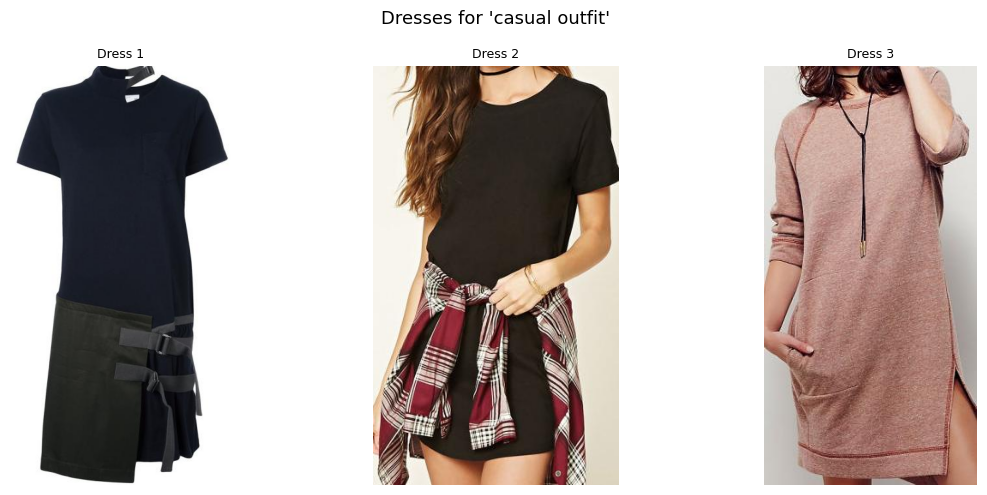

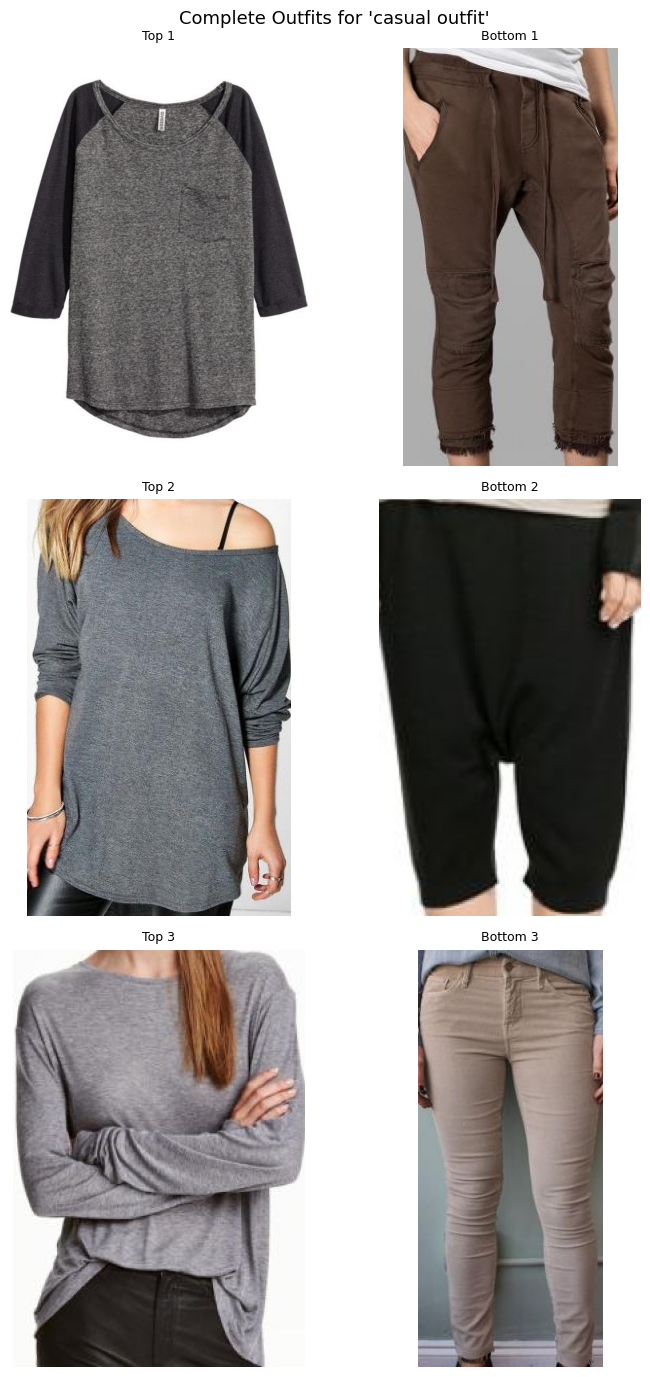

Detected intent: dress


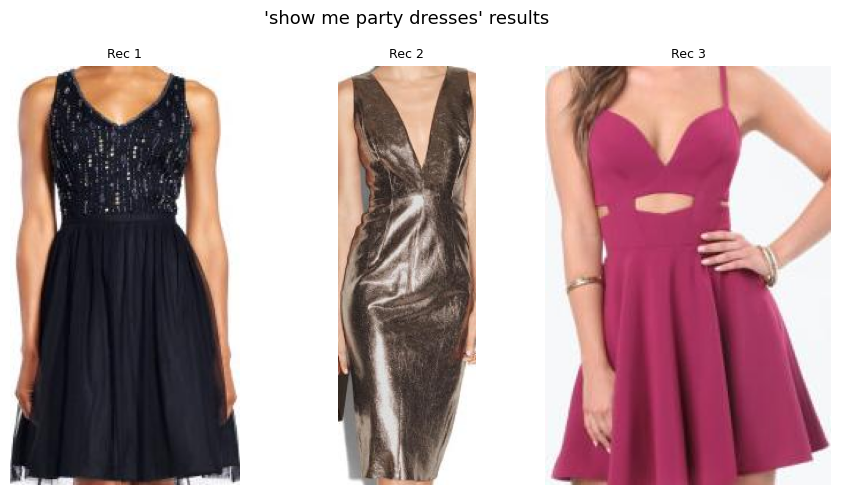

Input image detected as: solid


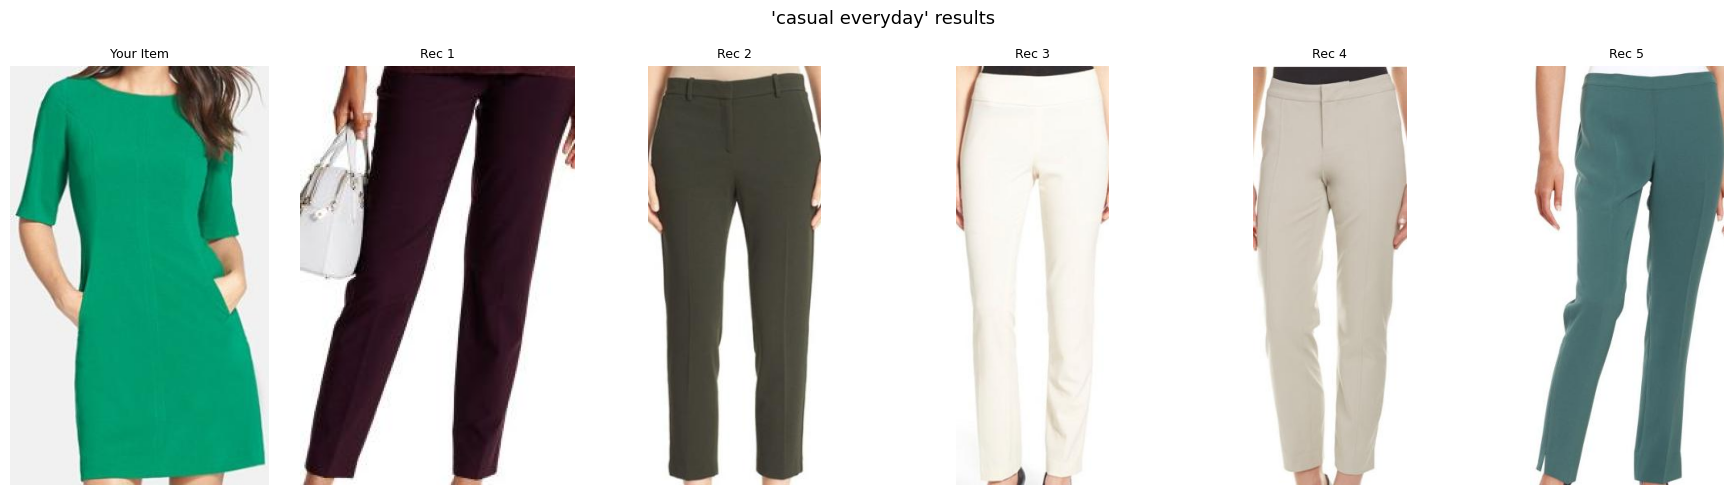

Input image detected as: solid


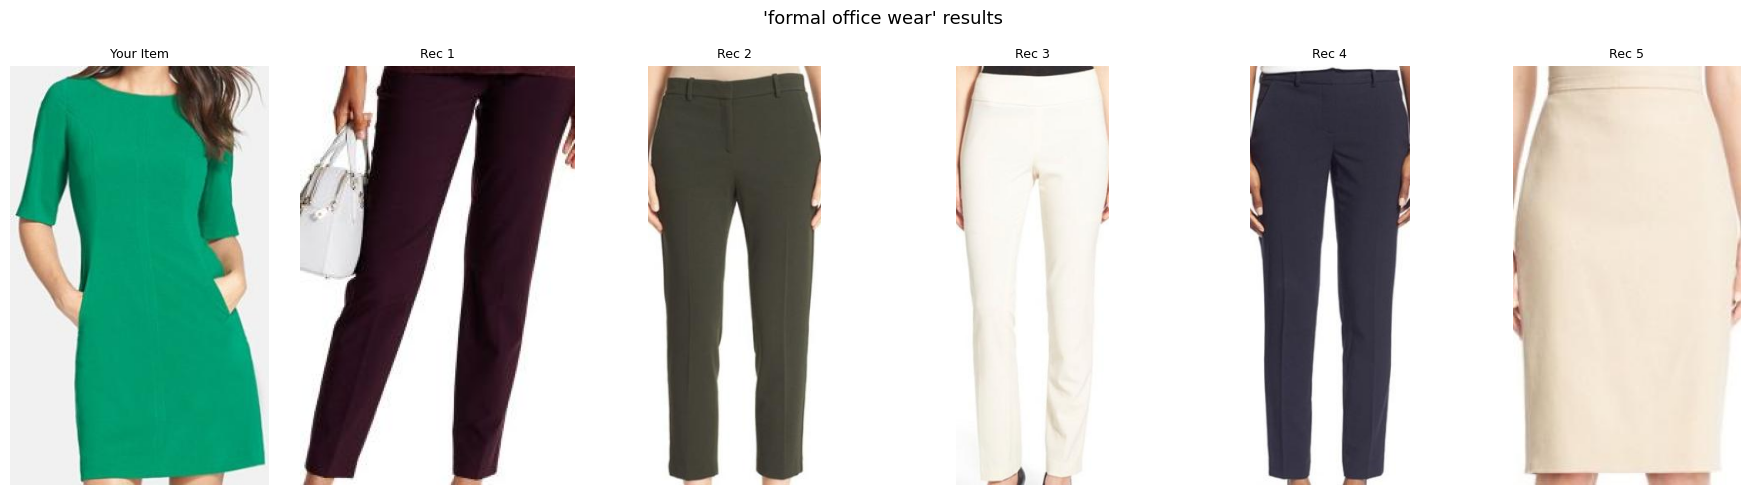

In [23]:
# ── Style filter helpers ───────────────────────────────────────────────────
PATTERN_WORDS = ["floral", "print", "pattern", "stripe", "stripes", "striped",
                 "plaid", "check", "checkered", "polka", "dot", "graphic",
                 "animal", "leopard", "zebra", "tie-dye", "abstract", "geometric"]

CLASH_PAIRS = [
    {"red", "orange"}, {"red", "pink"}, {"red", "purple"},
    {"orange", "pink"}, {"orange", "purple"},
    {"yellow", "green"}, {"blue", "green"},
]

COLOR_WORDS = ["red", "orange", "yellow", "green", "blue", "purple",
               "pink", "white", "black", "grey", "gray", "brown", "navy"]

def is_patterned(text):
    t = str(text).lower()
    return any(w in t for w in PATTERN_WORDS)

def get_colors(text):
    t = str(text).lower()
    return {c for c in COLOR_WORDS if c in t}

def colors_clash(text_a, text_b):
    colors_a = get_colors(text_a)
    colors_b = get_colors(text_b)
    for pair in CLASH_PAIRS:
        if colors_a & pair and colors_b & pair:
            return True
    return False

# ── Image lookup ───────────────────────────────────────────────────────────
def get_item_image(item_id):
    idx = id_to_index[str(item_id)]
    return ds_f200k_filtered[idx]["image"]

# ── Core helpers ───────────────────────────────────────────────────────────
def detect_intent(text):
    text_lower = text.lower()
    if any(word in text_lower for word in ["dress", "gown", "frock"]):
        return "dress"
    elif any(word in text_lower for word in ["top", "shirt", "blouse", "sweater", "jacket"]):
        return "top"
    elif any(word in text_lower for word in ["bottom", "pants", "skirt", "jeans", "trousers"]):
        return "bottom"
    else:
        return "full_outfit"

def get_image_features(pil_image):
    if pil_image.mode != "RGB":
        pil_image = pil_image.convert("RGB")
    tensor = preprocess(pil_image).unsqueeze(0).to(device)
    with torch.no_grad():
        features = clip_model.encode_image(tensor)
        features = features / features.norm(dim=-1, keepdim=True)
    return features.cpu().numpy().astype("float32")

def get_text_features(text):
    tokens = tokenizer([text]).to(device)
    with torch.no_grad():
        features = clip_model.encode_text(tokens)
        features = features / features.norm(dim=-1, keepdim=True)
    return features.cpu().numpy().astype("float32")

def siamese_score(query_vec, candidate_vecs):
    query_tensor = torch.tensor(
        np.tile(query_vec, (len(candidate_vecs), 1)), dtype=torch.float32
    ).to(device)
    cand_tensor = torch.tensor(candidate_vecs, dtype=torch.float32).to(device)
    with torch.no_grad():
        logits = model(query_tensor, cand_tensor)
        scores = torch.sigmoid(logits).cpu().numpy()
    return scores

# ── Text recommendation ────────────────────────────────────────────────────
def recommend_from_text(text, top_k=3, n_candidates=200):
    query_vec = get_text_features(text)
    intent    = detect_intent(text)
    print(f"Detected intent: {intent}")

    if intent == "dress":
        _, indices = index_dresses.search(query_vec, top_k + 10)
        ids  = df_dresses.iloc[indices[0]]["item_ID"].tolist()[:top_k]
        imgs = [get_item_image(iid) for iid in ids]
        meta = df_dresses.iloc[indices[0]].copy().reset_index(drop=True).head(top_k)
        return {"mode": "dress", "items": imgs, "meta": meta}

    elif intent == "top":
        _, indices = index_tops.search(query_vec, top_k + 10)
        ids  = df_tops.iloc[indices[0]]["item_ID"].tolist()[:top_k]
        imgs = [get_item_image(iid) for iid in ids]
        meta = df_tops.iloc[indices[0]].copy().reset_index(drop=True).head(top_k)
        return {"mode": "top", "items": imgs, "meta": meta}

    elif intent == "bottom":
        _, indices = index_bottoms.search(query_vec, top_k + 10)
        ids  = df_bottoms.iloc[indices[0]]["item_ID"].tolist()[:top_k]
        imgs = [get_item_image(iid) for iid in ids]
        meta = df_bottoms.iloc[indices[0]].copy().reset_index(drop=True).head(top_k)
        return {"mode": "bottom", "items": imgs, "meta": meta}

    else:
        # Dresses section
        _, dress_indices = index_dresses.search(query_vec, top_k)
        dress_ids  = df_dresses.iloc[dress_indices[0]]["item_ID"].tolist()
        dress_imgs = [get_item_image(iid) for iid in dress_ids]
        dress_meta = df_dresses.iloc[dress_indices[0]].copy().reset_index(drop=True)

        # Complete outfits section
        _, top_indices = index_tops.search(query_vec, n_candidates)
        top_ids  = df_tops.iloc[top_indices[0]]["item_ID"].tolist()
        top_vecs = np.stack([feature_dict_f200k[iid] for iid in top_ids]).astype("float32")
        top_meta = df_tops.iloc[top_indices[0]].copy().reset_index(drop=True)

        _, bot_indices = index_bottoms.search(query_vec, n_candidates)
        bot_ids  = df_bottoms.iloc[bot_indices[0]]["item_ID"].tolist()
        bot_vecs = np.stack([feature_dict_f200k[iid] for iid in bot_ids]).astype("float32")
        bot_meta = df_bottoms.iloc[bot_indices[0]].copy().reset_index(drop=True)

        outfit_pairs = []
        for t_idx in range(len(top_ids)):
            scores       = siamese_score(top_vecs[t_idx], bot_vecs)
            best_bot_idx = np.argmax(scores)
            outfit_pairs.append({
                "top_id":    top_ids[t_idx],
                "bottom_id": bot_ids[best_bot_idx],
                "top_text":  top_meta.iloc[t_idx]["text"],
                "bot_text":  bot_meta.iloc[best_bot_idx]["text"],
                "score":     scores[best_bot_idx]
            })

        outfit_pairs = sorted(outfit_pairs, key=lambda x: x["score"], reverse=True)

        # Filtered selection — no pattern-on-pattern, no color clashes
        seen_bottoms = set()
        unique_pairs = []
        for pair in outfit_pairs:
            if pair["bottom_id"] in seen_bottoms:
                continue
            if is_patterned(pair["top_text"]) and is_patterned(pair["bot_text"]):
                continue
            if colors_clash(pair["top_text"], pair["bot_text"]):
                continue
            seen_bottoms.add(pair["bottom_id"])
            unique_pairs.append(pair)
            if len(unique_pairs) == top_k:
                break

        # Fallback — filters too strict, fill remaining without rules
        if len(unique_pairs) < top_k:
            for pair in outfit_pairs:
                if pair["bottom_id"] not in seen_bottoms:
                    seen_bottoms.add(pair["bottom_id"])
                    unique_pairs.append(pair)
                if len(unique_pairs) == top_k:
                    break

        outfit_imgs = [(get_item_image(p["top_id"]), get_item_image(p["bottom_id"])) for p in unique_pairs]

        return {
            "mode":         "full_outfit",
            "dress_imgs":   dress_imgs,
            "dress_meta":   dress_meta,
            "outfit_imgs":  outfit_imgs,
            "outfit_pairs": unique_pairs
        }
def get_image_description_from_clip(pil_image):
    """
    Use CLIP zero-shot to detect if uploaded image is patterned/solid
    and its dominant color.
    """
    pattern_labels = [
        "a floral pattern top", "a striped top", "a plain solid color top",
        "a checkered pattern", "a graphic print top", "a solid plain garment"
    ]
    
    image_tensor = preprocess(pil_image).unsqueeze(0).to(device)
    tokens = tokenizer(pattern_labels).to(device)
    
    with torch.no_grad():
        image_features = clip_model.encode_image(image_tensor)
        text_features  = clip_model.encode_text(tokens)
        image_features /= image_features.norm(dim=-1, keepdim=True)
        text_features  /= text_features.norm(dim=-1, keepdim=True)
        probs = (image_features @ text_features.T).softmax(dim=-1)
    
    best_label = pattern_labels[probs.argmax().item()]
    is_busy    = "solid" not in best_label and "plain" not in best_label
    return best_label, is_busy

# ── Image + text recommendation ────────────────────────────────────────────
def recommend_from_image_and_text(pil_image, text, garment_type="top", top_k=5, n_candidates=200):
    image_vec = get_image_features(pil_image)
    text_vec  = get_text_features(text)

    if garment_type == "top":
        search_index = index_bottoms
        search_df    = df_bottoms
    elif garment_type == "bottom":
        search_index = index_tops
        search_df    = df_tops
    elif garment_type == "dress":
        search_df    = df_tops[df_tops["category1"] == "jackets"].reset_index(drop=True)
        jacket_vecs  = np.stack([feature_dict_f200k[iid] for iid in search_df["item_ID"]]).astype("float32")
        search_index = faiss.IndexFlatIP(512)
        search_index.add(jacket_vecs)

    # Blend image + text for FAISS query
    combined_vec = 0.6 * image_vec + 0.4 * text_vec
    combined_vec = combined_vec / np.linalg.norm(combined_vec, axis=-1, keepdims=True)

    _, cand_indices = search_index.search(combined_vec, n_candidates)

    candidate_ids  = search_df.iloc[cand_indices[0]]["item_ID"].tolist()
    candidate_meta = search_df.iloc[cand_indices[0]].copy().reset_index(drop=True)

    # Get vectors for scoring
    candidate_vecs = np.stack([feature_dict_f200k[iid] for iid in candidate_ids]).astype("float32")
    scores = siamese_score(image_vec[0], candidate_vecs)
    scores = apply_feedback_to_scores(candidate_meta, scores, feature_dict_f200k)

    candidate_meta["item_ID"] = candidate_ids
    candidate_meta["score"]   = scores

    # Detect if input image is patterned (do this ONCE, outside the loop)
    _, input_is_busy = get_image_description_from_clip(pil_image)
    print(f"Input image detected as: {'patterned' if input_is_busy else 'solid'}")

    # Sort by score first
    candidate_meta = candidate_meta.sort_values("score", ascending=False).reset_index(drop=True)

    input_text = str(text).lower()
    seen_cats  = {}
    filtered_rows = []

    for _, row in candidate_meta.iterrows():
        candidate_text = str(row["text"]).lower()

        # Rule 1: avoid pattern-on-pattern (using image detection)
        if input_is_busy and is_patterned(candidate_text):
            continue

        # Rule 2: avoid color clashes
        if colors_clash(input_text, candidate_text):
            continue

        # Diversity rule: max 2 per sub-category
        cat   = row.get("category2", row.get("category1", "unknown"))
        count = seen_cats.get(cat, 0)

        if count < 2:
            filtered_rows.append(row)
            seen_cats[cat] = count + 1

        if len(filtered_rows) == top_k:
            break

    # Fallback 1 — filters too strict, relax pattern/color rules
    if len(filtered_rows) < top_k:
        used_ids = {row["item_ID"] for row in filtered_rows}

        for _, row in candidate_meta.iterrows():
            if row["item_ID"] in used_ids:
                continue

            cat   = row.get("category2", row.get("category1", "unknown"))
            count = seen_cats.get(cat, 0)

            if count < 2:
                filtered_rows.append(row)
                seen_cats[cat] = count + 1
                used_ids.add(row["item_ID"])

            if len(filtered_rows) == top_k:
                break

    # Fallback 2 — fill remaining without any restriction
    if len(filtered_rows) < top_k:
        used_ids = {row["item_ID"] for row in filtered_rows}

        for _, row in candidate_meta.iterrows():
            if row["item_ID"] not in used_ids:
                filtered_rows.append(row)
                used_ids.add(row["item_ID"])

            if len(filtered_rows) == top_k:
                break

    final_meta       = pd.DataFrame(filtered_rows).reset_index(drop=True)
    recommend_images = [get_item_image(iid) for iid in final_meta["item_ID"]]

    return {
        "mode":  garment_type,
        "items": recommend_images,
        "meta":  final_meta
    }
# ── Display ────────────────────────────────────────────────────────────────
def display_results(result, input_image=None, query_text=""):
    if result["mode"] == "full_outfit":
        fig, axes = plt.subplots(1, 3, figsize=(12, 5))
        fig.suptitle(f"Dresses for '{query_text}'", fontsize=13)
        for i, img in enumerate(result["dress_imgs"]):
            axes[i].imshow(img)
            axes[i].set_title(f"Dress {i+1}", fontsize=9)
            axes[i].axis("off")
        plt.tight_layout()
        plt.show()

        fig, axes = plt.subplots(3, 2, figsize=(8, 14))
        fig.suptitle(f"Complete Outfits for '{query_text}'", fontsize=13)
        for i, (top_img, bot_img) in enumerate(result["outfit_imgs"]):
            axes[i][0].imshow(top_img)
            axes[i][0].set_title(f"Top {i+1}", fontsize=9)
            axes[i][0].axis("off")
            axes[i][1].imshow(bot_img)
            axes[i][1].set_title(f"Bottom {i+1}", fontsize=9)
            axes[i][1].axis("off")
        plt.tight_layout()
        plt.show()

    else:
        items = result["items"]
        cols  = len(items) + (1 if input_image else 0)
        fig, axes = plt.subplots(1, cols, figsize=(cols * 3, 5))
        if cols == 1:
            axes = [axes]
        idx = 0
        if input_image:
            axes[idx].imshow(input_image)
            axes[idx].set_title("Your Item", fontsize=9)
            axes[idx].axis("off")
            idx += 1
        for i, img in enumerate(items):
            axes[idx].imshow(img)
            axes[idx].set_title(f"Rec {i+1}", fontsize=9)
            axes[idx].axis("off")
            idx += 1
        fig.suptitle(f"'{query_text}' results", fontsize=13)
        plt.tight_layout()
        plt.show()

print("All functions ready!")

# ── Tests ──────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

# Test 1 — full outfit
result = recommend_from_text("casual outfit")
display_results(result, query_text="casual outfit")

# Test 2 — dresses only
result = recommend_from_text("show me party dresses")
display_results(result, query_text="show me party dresses")

# Test 3 — image + text using catalog image
test_img = ds_f200k_filtered[0]["image"]
result   = recommend_from_image_and_text(test_img, "casual everyday", garment_type="top")
display_results(result, input_image=test_img, query_text="casual everyday")

# Test 4 — image + text, formal mood
result = recommend_from_image_and_text(test_img, "formal office wear", garment_type="top")
display_results(result, input_image=test_img, query_text="formal office wear")

Input image detected as: solid


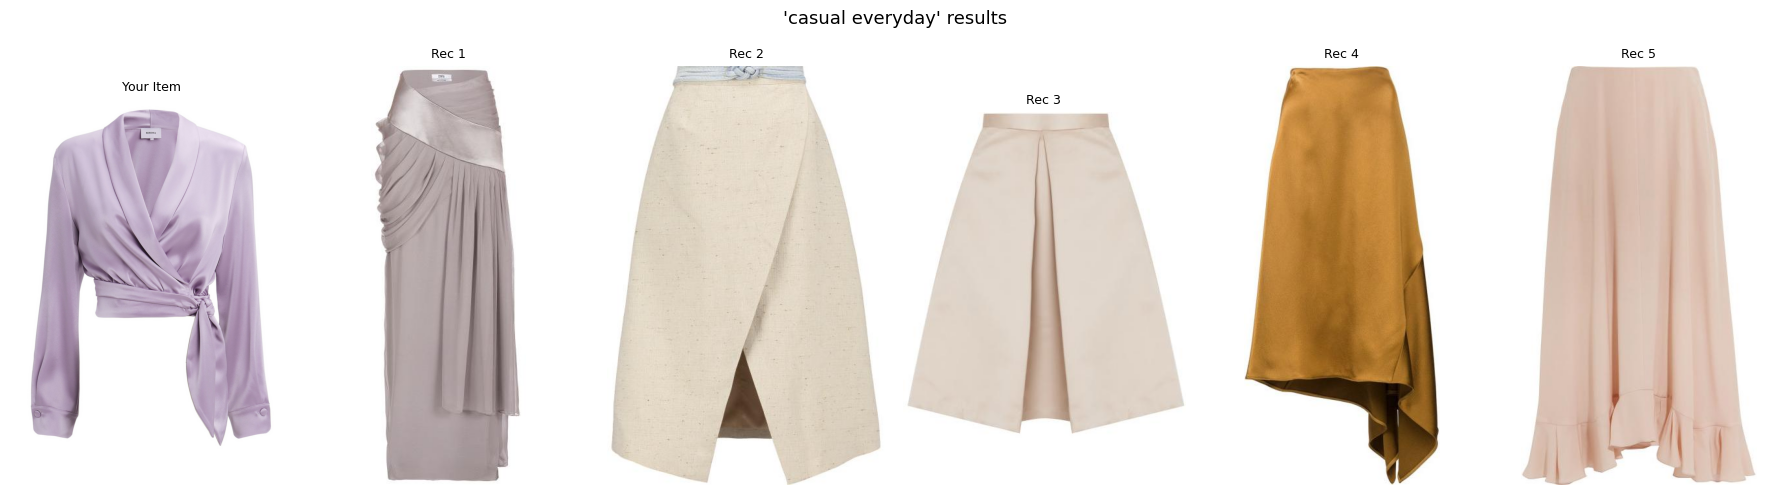


Rate each recommendation (1=👍 good, 0=👎 bad, s=skip):
    ✅ Saved as liked
    ⏭ Skipped
    ✅ Saved as liked
    ❌ Saved as disliked
    ✅ Saved as liked

Feedback saved! Future recommendations will improve.


In [24]:
from PIL import Image

# ── Upload your own image here ────────────────────────────────────────────
# Option 1 — local file
my_image = Image.open(r"C:\Users\shriy\OneDrive\Documents\ML-PROJECT-main\mytop.jpg").convert("RGB")

# Option 2 — use any catalog image by index
# my_image = ds_f200k_filtered[500]["image"]

# ── Change these as you like ──────────────────────────────────────────────
mood         = "casual everyday"   # e.g. "party night", "formal office", "beach day"
garment_type = "top"               # "top", "bottom", or "dress"

# ── Run ───────────────────────────────────────────────────────────────────
result = recommend_from_image_and_text(my_image, mood, garment_type=garment_type)
display_results(result, input_image=my_image, query_text=mood)

rate_recommendations(result)

TEST 3: Image + Text
Input image detected as: solid


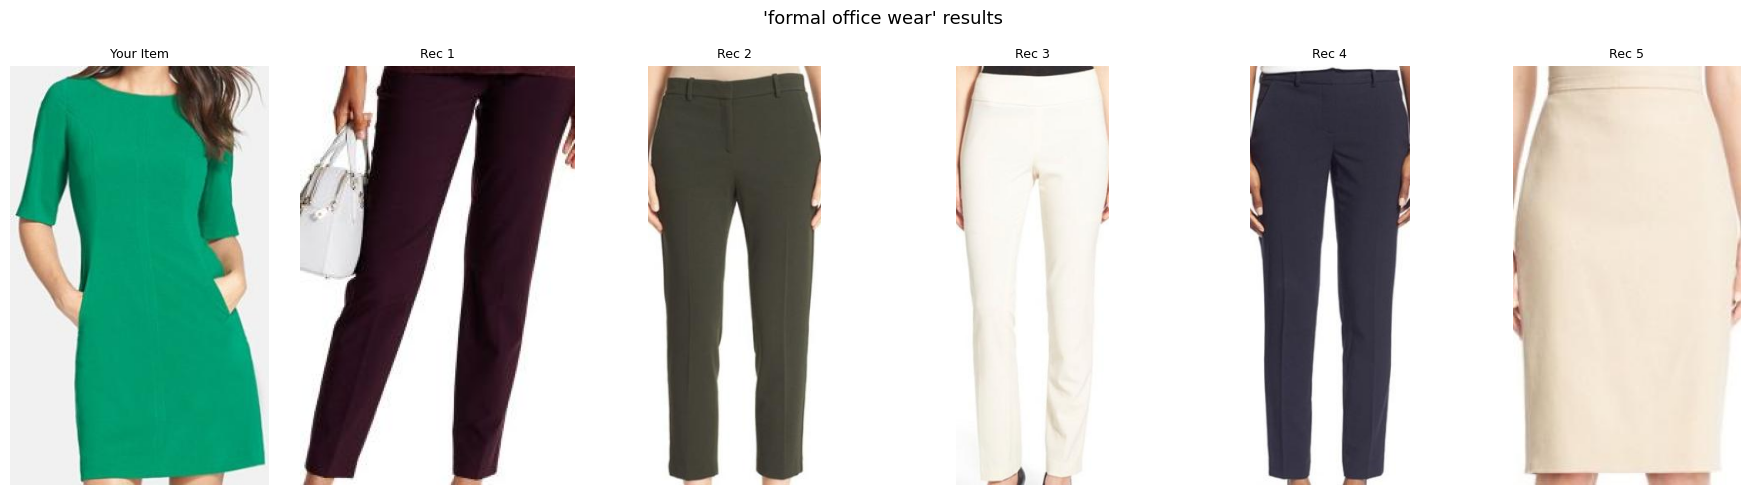

In [25]:
# Test 3 — Image + Text
print("="*50)
print("TEST 3: Image + Text")
print("="*50)

# Define test_image first
test_image = ds_f200k_filtered[0]["image"]  # grabs first image from your dataset

result = recommend_from_image_and_text(
    test_image,
    text="formal office wear",
    garment_type="top"
)

display_results(result, input_image=test_image, query_text="formal office wear")

In [26]:
import subprocess
subprocess.run(["pip", "install", "gradio"], check=True)

CompletedProcess(args=['pip', 'install', 'gradio'], returncode=0)

In [27]:
import gradio as gr
from PIL import Image

def run_recommendation(image, text, garment_type):
    """Main function called by Gradio"""
    
    # ── Image + Text mode ─────────────────────────────────────────────────
    if image is not None and text.strip() != "":
        result = recommend_from_image_and_text(
            image, text, garment_type=garment_type.lower()
        )
        output_images = result["items"]
        
        # Pad to 5 images
        while len(output_images) < 5:
            output_images.append(None)
        
        return (
            output_images[0], output_images[1], output_images[2],
            output_images[3], output_images[4],
            None, None, None,  # dress slots empty
            None, None, None, None, None, None  # outfit pair slots empty
        )

    # ── Text only mode ────────────────────────────────────────────────────
    elif image is None and text.strip() != "":
        result = recommend_from_text(text)

        if result["mode"] == "full_outfit":
            # 3 dresses + 3 outfit pairs
            dress_imgs = result["dress_imgs"]
            while len(dress_imgs) < 3:
                dress_imgs.append(None)

            pair_imgs = []
            for top_img, bot_img in result["outfit_imgs"]:
                pair_imgs.append(top_img)
                pair_imgs.append(bot_img)
            while len(pair_imgs) < 6:
                pair_imgs.append(None)

            return (
                None, None, None, None, None,  # image+text slots empty
                dress_imgs[0], dress_imgs[1], dress_imgs[2],  # dresses
                pair_imgs[0], pair_imgs[1],    # outfit 1
                pair_imgs[2], pair_imgs[3],    # outfit 2
                pair_imgs[4], pair_imgs[5]     # outfit 3
            )

        else:
            # Single category (dress/top/bottom only)
            items = result["items"]
            while len(items) < 3:
                items.append(None)
            return (
                None, None, None, None, None,
                items[0], items[1], items[2],
                None, None, None, None, None, None
            )

    else:
        return tuple([None] * 14)


# ── Gradio UI ─────────────────────────────────────────────────────────────
with gr.Blocks(title="Outfit Recommender") as demo:
    gr.Markdown("# 👗 Outfit Compatibility Recommender")
    gr.Markdown("Upload a garment image and/or describe your mood to get outfit recommendations.")

    with gr.Row():
        with gr.Column(scale=1):
            image_input   = gr.Image(type="pil", label="Upload your garment (optional)")
            text_input    = gr.Textbox(label="Describe your mood or occasion", 
                                       placeholder="e.g. casual beach day, formal meeting, party night")
            garment_input = gr.Dropdown(
                choices=["top", "bottom", "dress"],
                value="top",
                label="What are you uploading? (only for image mode)"
            )
            submit_btn = gr.Button("Get Recommendations", variant="primary")

        with gr.Column(scale=2):
            # Image + text results
            gr.Markdown("### 🔍 Compatible Items (Image + Mood)")
            with gr.Row():
                img_out1 = gr.Image(label="Rec 1", height=200)
                img_out2 = gr.Image(label="Rec 2", height=200)
                img_out3 = gr.Image(label="Rec 3", height=200)
                img_out4 = gr.Image(label="Rec 4", height=200)
                img_out5 = gr.Image(label="Rec 5", height=200)

            # Text only — dresses
            gr.Markdown("### 👗 Dresses (Text mode)")
            with gr.Row():
                dress_out1 = gr.Image(label="Dress 1", height=200)
                dress_out2 = gr.Image(label="Dress 2", height=200)
                dress_out3 = gr.Image(label="Dress 3", height=200)

            # Text only — complete outfits
            gr.Markdown("### 👔 Complete Outfits (Text mode)")
            with gr.Row():
                pair1_top = gr.Image(label="Outfit 1 - Top",    height=200)
                pair1_bot = gr.Image(label="Outfit 1 - Bottom", height=200)
                pair2_top = gr.Image(label="Outfit 2 - Top",    height=200)
                pair2_bot = gr.Image(label="Outfit 2 - Bottom", height=200)
                pair3_top = gr.Image(label="Outfit 3 - Top",    height=200)
                pair3_bot = gr.Image(label="Outfit 3 - Bottom", height=200)

    submit_btn.click(
        fn=run_recommendation,
        inputs=[image_input, text_input, garment_input],
        outputs=[
            img_out1, img_out2, img_out3, img_out4, img_out5,
            dress_out1, dress_out2, dress_out3,
            pair1_top, pair1_bot,
            pair2_top, pair2_bot,
            pair3_top, pair3_bot
        ]
    )

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://7c4f735bbfb69787d0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# import numpy as np

# model.eval()
# all_preds = []
# all_labels = []

# with torch.no_grad():
#     for vec_A, vec_B, label in val_loader:
        
#         dist = model(vec_A, vec_B)   # ✅ model already gives distance
        
#         predicted = (dist < 0.5).float()
        
#         all_preds.extend(predicted.cpu().numpy())
#         all_labels.extend(label.cpu().numpy())

# all_preds = np.array(all_preds)
# all_labels = np.array(all_labels)

# accuracy = accuracy_score(all_labels, all_preds) * 100
# precision = precision_score(all_labels, all_preds) * 100
# recall = recall_score(all_labels, all_preds) * 100
# f1 = f1_score(all_labels, all_preds) * 100

# print(f"Accuracy: {accuracy:.1f}%")
# print(f"Precision: {precision:.1f}%")
# print(f"Recall: {recall:.1f}%")
# print(f"F1 Score: {f1:.1f}%")

Accuracy: 34.3%
Precision: 35.9%
Recall: 39.9%
F1 Score: 37.8%


In [ ]:
# import torch
# import numpy as np
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# import clip

# device = "cuda" if torch.cuda.is_available() else "cpu"

# model, _ = clip.load("ViT-B/32", device=device)
# model.eval()

# all_preds = []
# all_labels = []

# threshold = 0.3

# with torch.no_grad():
#     for image_features, texts, labels in val_loader:
        
#         # ✅ image_features already embeddings
#         image_features = image_features.to(device).float()
        
#         # Handle text
#         if isinstance(texts, torch.Tensor):
#             text_features = texts.to(device).float()
#         else:
#             texts = clip.tokenize(texts).to(device)
#             text_features = model.encode_text(texts)
        
#         # Normalize
#         image_features = image_features / image_features.norm(dim=-1, keepdim=True)
#         text_features = text_features / text_features.norm(dim=-1, keepdim=True)
        
#         # Similarity
#         similarity = (image_features * text_features).sum(dim=-1)
        
#         predicted = (similarity > threshold).float()
        
#         all_preds.extend(predicted.cpu().numpy())
#         all_labels.extend(labels.cpu().numpy())

# all_preds = np.array(all_preds)
# all_labels = np.array(all_labels)

# accuracy = accuracy_score(all_labels, all_preds) * 100
# precision = precision_score(all_labels, all_preds) * 100
# recall = recall_score(all_labels, all_preds) * 100
# f1 = f1_score(all_labels, all_preds) * 100

# print("CLIP Results:")
# print(f"Accuracy: {accuracy:.1f}%")
# print(f"Precision: {precision:.1f}%")
# print(f"Recall: {recall:.1f}%")
# print(f"F1 Score: {f1:.1f}%")

CLIP Results:
Accuracy: 50.0%
Precision: 50.0%
Recall: 100.0%
F1 Score: 66.6%
